
🚀 Training with lambda = 1e-05
Epoch 1 | Loss: 661.85 | Acc: 46.74% | Sparsity: 0.00%
Epoch 2 | Loss: 783.02 | Acc: 49.79% | Sparsity: 0.00%
Epoch 3 | Loss: 937.17 | Acc: 51.54% | Sparsity: 0.00%
Epoch 4 | Loss: 1081.06 | Acc: 53.77% | Sparsity: 0.01%
Epoch 5 | Loss: 1211.43 | Acc: 54.49% | Sparsity: 0.04%
Epoch 6 | Loss: 1323.54 | Acc: 54.29% | Sparsity: 0.14%
Epoch 7 | Loss: 1424.91 | Acc: 55.47% | Sparsity: 0.36%
Epoch 8 | Loss: 1510.89 | Acc: 55.62% | Sparsity: 0.74%
Epoch 9 | Loss: 1588.03 | Acc: 55.49% | Sparsity: 1.31%
Epoch 10 | Loss: 1655.87 | Acc: 55.44% | Sparsity: 2.08%
Epoch 11 | Loss: 1713.15 | Acc: 55.58% | Sparsity: 3.04%
Epoch 12 | Loss: 1766.61 | Acc: 55.66% | Sparsity: 4.18%
Epoch 13 | Loss: 1814.29 | Acc: 55.23% | Sparsity: 5.49%
Epoch 14 | Loss: 1856.41 | Acc: 55.64% | Sparsity: 6.93%
Epoch 15 | Loss: 1893.92 | Acc: 55.60% | Sparsity: 8.51%

🚀 Training with lambda = 0.0001
Epoch 1 | Loss: 663.05 | Acc: 46.37% | Sparsity: 0.00%
Epoch 2 | Loss: 2601.14 | Acc: 50.86%

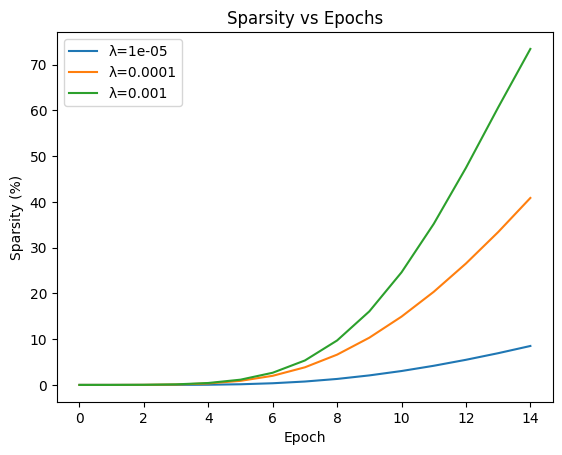


📊 FINAL RESULTS
Lambda		Accuracy	Sparsity
1e-05	55.60%		8.51%
0.0001	56.60%		40.85%
0.001	51.05%		73.41%


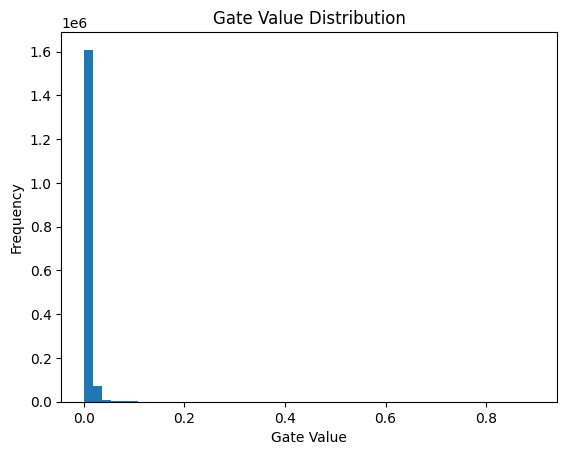

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =========================
# Prunable Linear Layer
# =========================
class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()

        self.weight = nn.Parameter(torch.randn(out_features, in_features) * 0.01)
        self.bias = nn.Parameter(torch.zeros(out_features))

        self.gate_scores = nn.Parameter(torch.randn(out_features, in_features))

    def forward(self, x):
        # 🔥 Temperature scaling (important upgrade)
        temperature = 0.5
        gates = torch.sigmoid(self.gate_scores / temperature)

        pruned_weights = self.weight * gates
        return F.linear(x, pruned_weights, self.bias)


# =========================
# Model
# =========================
class PrunableNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.fc1 = PrunableLinear(32 * 32 * 3, 512)
        self.fc2 = PrunableLinear(512, 256)
        self.fc3 = PrunableLinear(256, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


# =========================
# Sparsity Loss
# =========================
def compute_sparsity_loss(model):
    loss = 0.0
    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(module.gate_scores)
            loss += torch.sum(gates)
    return loss


# =========================
# Sparsity %
# =========================
def calculate_sparsity(model, threshold=1e-2):
    total = 0
    zero = 0

    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(module.gate_scores)
            total += gates.numel()
            zero += (gates < threshold).sum().item()

    return 100 * zero / total


# =========================
# Hard Pruning
# =========================
def apply_hard_pruning(model, threshold=1e-2):
    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(module.gate_scores)
            mask = (gates > threshold).float()
            module.weight.data *= mask


# =========================
# Data
# =========================
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

trainset = torchvision.datasets.CIFAR10(root="./data", train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True)

testset = torchvision.datasets.CIFAR10(root="./data", train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=128, shuffle=False)


# =========================
# Evaluation
# =========================
def evaluate(model):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return 100 * correct / total


# =========================
# Training Function
# =========================
def train_model(lambda_sparse):

    model = PrunableNet().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()

    epochs = 15

    sparsity_history = []
    acc_history = []

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            ce_loss = criterion(outputs, labels)

            sparsity_loss = compute_sparsity_loss(model)

            # 🔥 Progressive lambda
            current_lambda = lambda_sparse * (epoch / epochs)

            loss = ce_loss + current_lambda * sparsity_loss

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        acc = evaluate(model)
        sparsity = calculate_sparsity(model)

        acc_history.append(acc)
        sparsity_history.append(sparsity)

        print(f"Epoch {epoch+1} | Loss: {total_loss:.2f} | Acc: {acc:.2f}% | Sparsity: {sparsity:.2f}%")

    return model, acc_history, sparsity_history


# =========================
# Experiments
# =========================
lambdas = [1e-5, 1e-4, 1e-3]
results = []

for lam in lambdas:
    print(f"\n🚀 Training with lambda = {lam}")

    model, acc_hist, sparsity_hist = train_model(lam)

    # 🔥 Apply hard pruning before final eval
    apply_hard_pruning(model)

    final_acc = evaluate(model)
    final_sparsity = calculate_sparsity(model)

    results.append((lam, final_acc, final_sparsity))

    # Plot sparsity curve
    plt.plot(sparsity_hist, label=f"λ={lam}")


# =========================
# Plot Sparsity Curve
# =========================
plt.title("Sparsity vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Sparsity (%)")
plt.legend()
plt.show()


# =========================
# Results Table
# =========================
print("\n📊 FINAL RESULTS")
print("Lambda\t\tAccuracy\tSparsity")

for r in results:
    print(f"{r[0]}\t{r[1]:.2f}%\t\t{r[2]:.2f}%")


# =========================
# Gate Distribution
# =========================
def plot_gate_distribution(model):
    all_gates = []

    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(module.gate_scores).detach().cpu().numpy()
            all_gates.extend(gates.flatten())

    plt.hist(all_gates, bins=50)
    plt.title("Gate Value Distribution")
    plt.xlabel("Gate Value")
    plt.ylabel("Frequency")
    plt.show()


plot_gate_distribution(model)